In [ ]:
# Cek apakah GPU terdeteksi
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Konfirmasi Library Tensorflow gunakan GPU juga
tf.test.gpu_device_name()

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


'/device:GPU:0'

In [ ]:
# Import keseluruhan library yang diperlukan
from google.colab import files
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
from tensorflow.keras.layers import Dropout
from sklearn.metrics import confusion_matrix
import sklearn
import matplotlib
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Cek Seluruh Versi Environment Utama yang Diggunakan
# !pip install -U scikit-learn matplotlib seaborn
# Python
import platform
print("Python Version: ", platform.python_version())

# Deep Learning
print("\n--- Deep Learning ---")
print("TensorFlow:", tf.__version__)

# Machine Learning
print("\n--- Machine Learning ---")
print("Scikit-learn:", sklearn.__version__)

# Data Processing
print("\n--- Data Processing ---")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

# NLP
print("\n--- NLP ---")
print("NLTK:", nltk.__version__)

# Visualization
print("\n--- Visualization ---")
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

Python Version:  3.12.13

--- Deep Learning ---
TensorFlow: 2.19.0

--- Machine Learning ---
Scikit-learn: 1.6.1

--- Data Processing ---
NumPy: 2.0.2
Pandas: 2.2.2

--- NLP ---
NLTK: 3.9.1

--- Visualization ---
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [ ]:
# Upload Dataset
file = files.upload()

Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv


In [ ]:
# Membuka Datasetnya
df = pd.read_csv('cyberbullying_tweets.csv')
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
# Preprocessing: convert uppercase to lowercase, remove insignificant symbols, tokenization, stopwords removal,
# lemmatization
# Download resource NLTK yang diperlukan
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Stopwords Bahasa Inggris
stop_words = set(stopwords.words('english'))

# Inisialisasi Lemmatizer
lemmatizer = WordNetLemmatizer()

# Fungsi Preprocessing
def clean_text(text):
    # Ubah NaN atau float jadi string kosong
    if not isinstance(text, str):
        text = ""
    # Ubah semua huruf besar menjadi huruf kecil
    text = text.lower()
    # Hilangkan semua simbol yang tidak penting
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # hanya huruf & spasi
    text = re.sub(r'\s+', ' ', text).strip()   # hapus whitespace berlebih
    text = re.sub(r'[^\w\s]', '', text)   # hapus semua tanda baca
    # Tokenisasi
    tokens = text.split()
    # Hilangkan Stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization (English)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Apply ke kolom clean tweet text
df['clean_tweet_text'] = df['tweet_text'].apply(clean_text)

# Cek hasil preprocessing
print(df[['tweet_text','clean_tweet_text']].head())

# Hapus kolom tweet text asli
df = df.drop(columns=['tweet_text'])
df.head()

# Jumlah data setelah preprocessing
print("Jumlah data:", len(df['clean_tweet_text']))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                          tweet_text  \
0  In other words #katandandre, your food was cra...   
1  Why is #aussietv so white? #MKR #theblock #ImA...   
2  @XochitlSuckkks a classy whore? Or more red ve...   
3  @Jason_Gio meh. :P  thanks for the heads up, b...   
4  @RudhoeEnglish This is an ISIS account pretend...   

                                    clean_tweet_text  
0             word katandandre food crapilicious mkr  
1  aussietv white mkr theblock imacelebrityau tod...  
2     xochitlsuckkks classy whore red velvet cupcake  
3  jason gio meh p thanks head concerned another ...  
4  rudhoeenglish isi account pretending kurdish a...  
Jumlah data: 47692


Dataset shape: (47692, 2)

Kolom dataset: ['cyberbullying_type', 'clean_tweet_text']

Missing values:
 cyberbullying_type    0
clean_tweet_text      0
dtype: int64

Jumlah baris duplikat (seluruh kolom): 338

Tipe Data Setiap Kolom:
 cyberbullying_type    object
clean_tweet_text      object
dtype: object

Panjang Maksimal Kata dalam Suatu Kalimat:  496


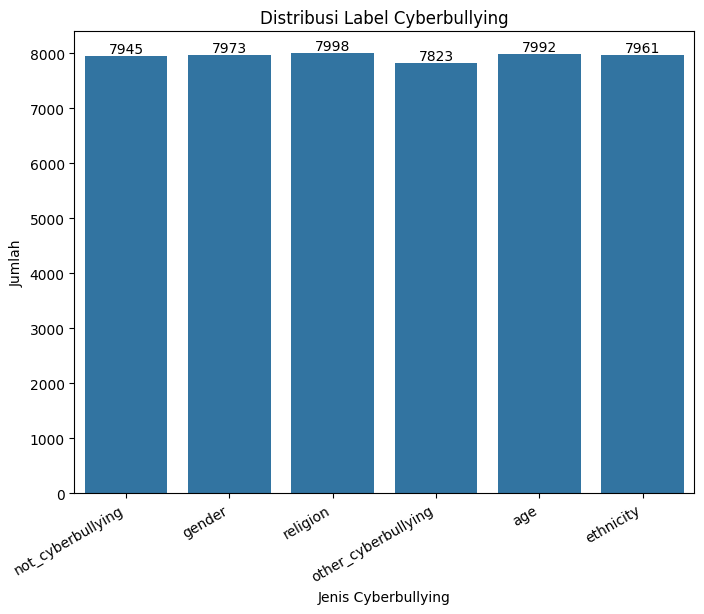

In [ ]:
# Exploratory Data Analysis
# 1. Informasi dasar dataset
print("Dataset shape:", df.shape)
print("\nKolom dataset:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

# --- Cek duplikat ---
duplicate_rows = df.duplicated().sum()
print("\nJumlah baris duplikat (seluruh kolom):", duplicate_rows)
# Cek Setiap Kolom menggunakan tipe data apa
print("\nTipe Data Setiap Kolom:\n", df.dtypes)

# 2. Cek Panjang Maksimal Kata dalam Suatu Kalimat
max_sen = df['clean_tweet_text'].str.split().str.len().max()
print("\nPanjang Maksimal Kata dalam Suatu Kalimat: ", max_sen)

# 3. Distribusi label
plt.figure(figsize=(8,6))
ax = sns.countplot(x='cyberbullying_type', data=df)

# Tambahkan angka di atas setiap bar
for container in ax.containers:
    ax.bar_label(container)

# Judul dan label
plt.title("Distribusi Label Cyberbullying")
plt.xlabel("Jenis Cyberbullying")
plt.ylabel("Jumlah")

# Rapikan tulisan di sumbu x
plt.xticks(rotation=30, ha='right')
plt.show()



Statistik jumlah kata:
 count    47692.000000
mean        13.896733
std          8.412591
min          0.000000
25%          8.000000
50%         12.000000
75%         18.000000
max        496.000000
Name: word_count, dtype: float64


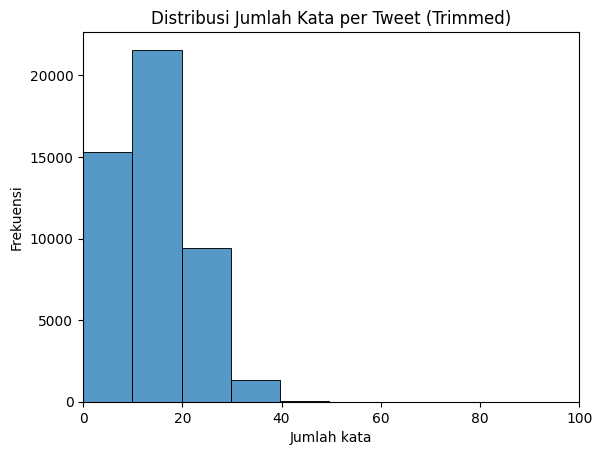


20 kata paling sering muncul:

       Word  Frequency
0    school       9302
1      fuck       6186
2      like       6038
3    nigger       5818
4         u       5730
5      joke       5644
6      girl       5620
7     bully       5442
8      dumb       5396
9      high       5268
10   muslim       5011
11   people       4946
12  bullied       4703
13     http       4619
14      gay       4619
15     rape       4529
16       rt       4358
17      one       3801
18    idiot       3526
19       co       3325


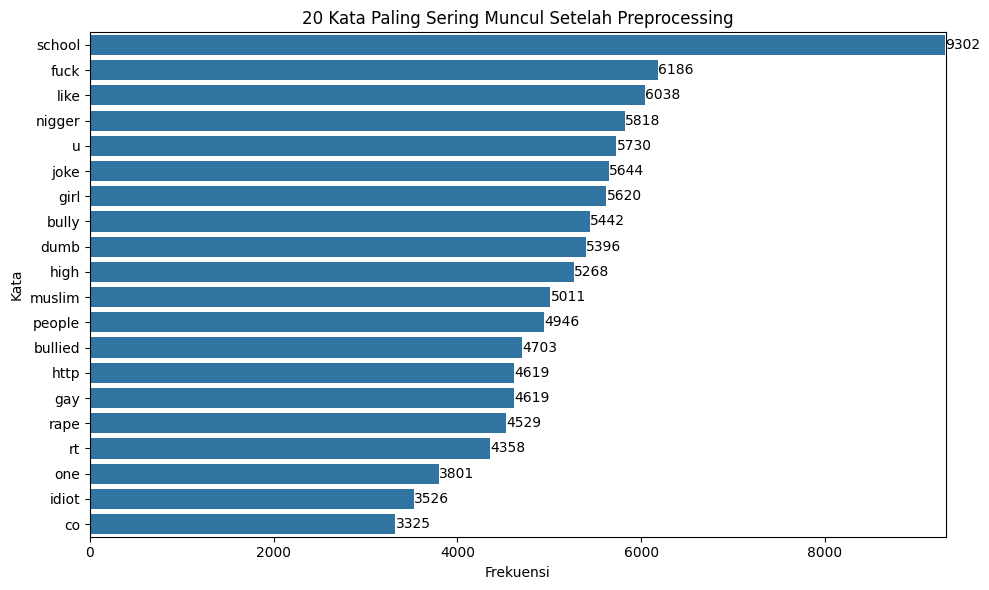


Contoh data setelah preprocessing:
                                         clean_tweet_text   cyberbullying_type
26651  antonsirius erinspice prpltnkr chiefelk oh dea...  other_cyberbullying
47240  give nigga pas canceled year old grown man tal...            ethnicity
26754  crazii bratz oshit bully part ok lol goin try ...  other_cyberbullying
11841  ever laughed rape joke ever laughed joke pedop...               gender
37931  girl bullied high school dating scooter boy th...                  age


In [ ]:
# 4. Jumlah kata per tweet
df['word_count'] = df['clean_tweet_text'].apply(lambda x: len(str(x).split()))
print("\nStatistik jumlah kata:\n", df['word_count'].describe())

sns.histplot(df['word_count'], bins=50)
plt.xlim(0, 100)
plt.title("Distribusi Jumlah Kata per Tweet (Trimmed)")
plt.xlabel("Jumlah kata")
plt.ylabel("Frekuensi")
plt.show()

# 5. Kata paling sering muncul (setelah preprocessing)
all_words = ' '.join(df['clean_tweet_text']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

# Convert ke DataFrame
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

print("\n20 kata paling sering muncul:\n")
print(common_df)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Frequency', y='Word', data=common_df)

# Tambahkan angka di setiap bar
for i, v in enumerate(common_df['Frequency']):
    ax.text(v + 1, i, str(v), color='black', va='center')

# Judul dan layout
plt.title("20 Kata Paling Sering Muncul Setelah Preprocessing")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

# Biar angka tidak kepotong
plt.xlim(0, common_df['Frequency'].max() + 10)

plt.tight_layout()
plt.show()

# 6. Contoh data setelah preprocessing
print("\nContoh data setelah preprocessing:\n",
      df[['clean_tweet_text','cyberbullying_type']].sample(5))

In [ ]:
# Langkah Preprocessing Tambahan: Hapus Missing Values dan Duplikat berdasarkan data yang sudah dibersihkan
df = df.dropna(subset=['clean_tweet_text','cyberbullying_type'])

# Cek jumlah data setelah dibersihkan
print("Jumlah data setelah drop nilai yang hilang:", len(df))

df = df.drop_duplicates(subset=['clean_tweet_text', 'cyberbullying_type'])

# Cek jumlah data setelah drop duplikat
print("Jumlah data setelah drop duplikat:", len(df))

# Urutkan kembali indeks setelah missing values dan nilai duplikat dihapus
df = df.reset_index(drop=True)
df.head()

Jumlah data setelah drop nilai yang hilang: 47692
Jumlah data setelah drop duplikat: 47354


,cyberbullying_type,clean_tweet_text,word_count
0,not_cyberbullying,word katandandre food crapilicious mkr,5
1,not_cyberbullying,aussietv white mkr theblock imacelebrityau tod...,11
2,not_cyberbullying,xochitlsuckkks classy whore red velvet cupcake,6
3,not_cyberbullying,jason gio meh p thanks head concerned another ...,11
4,not_cyberbullying,rudhoeenglish isi account pretending kurdish a...,9


In [ ]:
# Encode label
le = LabelEncoder()
df['cyberbullying_type_label_encoded'] = le.fit_transform(df['cyberbullying_type'])

# Cek hasil setelah encoding
df[['cyberbullying_type','cyberbullying_type_label_encoded']].head()

,cyberbullying_type,cyberbullying_type_label_encoded
0,not_cyberbullying,3
1,not_cyberbullying,3
2,not_cyberbullying,3
3,not_cyberbullying,3
4,not_cyberbullying,3


In [ ]:
# Konfigurasi Tokenisasi & Padding untuk GRU
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_tweet_text'])

X_seq = tokenizer.texts_to_sequences(df['clean_tweet_text'])
X_seq = pad_sequences(X_seq, maxlen=200)

In [ ]:
# Download Pre-Trained FastText English
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
!gunzip cc.en.300.vec.gz

--2026-04-27 11:53:14--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 143.204.1.46, 143.204.1.120, 143.204.1.38, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|143.204.1.46|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1325960915 (1.2G) [binary/octet-stream]
Saving to: ‘cc.en.300.vec.gz’

cc.en.300.vec.gz    100%[===================>]   1.23G  74.9MB/s    in 18s     

2026-04-27 11:53:32 (70.7 MB/s) - ‘cc.en.300.vec.gz’ saved [1325960915/1325960915]



In [ ]:
# Load Embedding Index untuk masukkan Word2Vec ke clean tweet text
embedding_index = {}
with open("cc.en.300.vec", encoding="utf-8") as f:
    for line in f:
        values = line.rstrip().split(" ")
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_dim = 300
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(max_features=30000,
                        ngram_range=(1,2),          # unigram + bigram
                        min_df=5,                   # buang kata terlalu jarang
                        max_df=0.8,                 # buang kata terlalu umum
                        sublinear_tf=True           # scaling TF
                        )

# Fit-transform ke clean tweet text
X = tfidf.fit_transform(df['clean_tweet_text'])

# Target
Y = df['cyberbullying_type_label_encoded']

In [ ]:
# Pemisahan Data dengan proporsi pembagian data sebesar 70:20:10 untuk TF-IDF dan Word2Vec mempersiapkan data untuk proses modelling MLP dan GRU
# Split TF-IDF
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, df['cyberbullying_type_label_encoded'], test_size=0.30, random_state=42, stratify=df['cyberbullying_type_label_encoded']
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.33, random_state=42, stratify=Y_temp
)

print("TF-IDF Train size:", X_train.shape[0])
print("TF-IDF Validation size:", X_val.shape[0])
print("TF-IDF Test size:", X_test.shape[0])

# Split Sequence (Word2Vec)
X_train_seq, X_temp_seq, Y_train_seq, Y_temp_seq = train_test_split(
    X_seq, df['cyberbullying_type_label_encoded'], test_size=0.30, random_state=42, stratify=df['cyberbullying_type_label_encoded']
)
X_val_seq, X_test_seq, Y_val_seq, Y_test_seq = train_test_split(
    X_temp_seq, Y_temp_seq, test_size=0.33, random_state=42, stratify=Y_temp_seq
)

print("Seq Train size:", X_train_seq.shape[0])
print("Seq Validation size:", X_val_seq.shape[0])
print("Seq Test size:", X_test_seq.shape[0])

TF-IDF Train size: 33147
TF-IDF Validation size: 9518
TF-IDF Test size: 4689
Seq Train size: 33147
Seq Validation size: 9518
Seq Test size: 4689


In [ ]:
# Normalisasi Data
scaler = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:

# Codingan under construction atau tidak aktif buat tesis S2 nanti karena kebetulan Dataset saya sama untuk project 2 DL, hanya berbeda model saja
# (Logistic Regression, Random Forest, dan MLP)
# Modelling & Evaluasi TF-IDF + Logistic Regression
# ============================================================
# logreg = LogisticRegression(
#     max_iter=1000,          # jumlah iterasi agar konvergen
#     random_state=42,
#     solver='lbfgs',         # solver default yang stabil
#     multi_class='auto'      # otomatis untuk multi-class
# )
# logreg.fit(X_train, Y_train)

In [ ]:
# Codingan under construction atau tidak aktif buat tesis S2 nanti karena kebetulan Dataset saya sama untuk project 2 DL, hanya berbeda model saja
# (Logistic Regression, Random Forest, dan MLP)
# Modelling & Evaluasi TF-IDF + Random Forest
# ============================================================
# rf = RandomForestClassifier(
#     n_estimators=200,       # jumlah pohon
#     max_depth=None,         # biarkan pohon tumbuh penuh
#     random_state=42,
#     n_jobs=-1               # gunakan semua core CPU
# )
# rf.fit(X_train, Y_train)

In [ ]:
# Modelling & Evaluasi TF-IDF + MLP
# Inisialisasi MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),   # hidden layer
    activation='relu',              # fungsi aktivasi
    solver='adam',                 # optimizer
    alpha = 1e-3,                 # regularisasi
    max_iter=20,                    # jumlah epoch
    random_state=42,
    early_stopping = True,
    validation_fraction = 0.2,
    verbose = True
)

# Training MLP
mlp.fit(X_train, Y_train)

Iteration 1, loss = 1.02054733
Validation score: 0.760483
Iteration 2, loss = 0.29589482
Validation score: 0.762443
Iteration 3, loss = 0.14675407
Validation score: 0.760633
Iteration 4, loss = 0.10661755
Validation score: 0.758069
Iteration 5, loss = 0.08887064
Validation score: 0.756259
Iteration 6, loss = 0.07943995
Validation score: 0.757164
Iteration 7, loss = 0.07351181
Validation score: 0.755053
Iteration 8, loss = 0.07227984
Validation score: 0.755204
Iteration 9, loss = 0.06674824
Validation score: 0.755807
Iteration 10, loss = 0.06340465
Validation score: 0.752489
Iteration 11, loss = 0.06188721
Validation score: 0.754902
Iteration 12, loss = 0.06018746
Validation score: 0.753243
Iteration 13, loss = 0.05831638
Validation score: 0.752338
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(32, 16),
              max_iter=20, random_state=42, validation_fraction=0.2,
              verbose=True)

In [ ]:
# Modelling & Evaluasi Word2Vec + GRU
# 1. Set seed global
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
tf.config.experimental.enable_op_determinism()

# 2. Definisikan model GRU multi-class
model = Sequential()
model.add(Embedding(
    input_dim=len(word_index) + 1,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=200,
    trainable=False
))
model.add(GRU(128, dropout = 0.2))   # GRU layer untuk sequence
model.add(Dense(6, activation='softmax'))  # output 6 kelas

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 3. Pelatihan
history = model.fit(
    X_train_seq, Y_train_seq,
    validation_data=(X_val_seq, Y_val_seq),
    epochs=20,
    batch_size=64,
    verbose=1
)

# 4. Evaluasi
loss, acc = model.evaluate(X_test_seq, Y_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7371 - loss: 0.6755 - val_accuracy: 0.8024 - val_loss: 0.4889
Epoch 2/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8093 - loss: 0.4726 - val_accuracy: 0.8208 - val_loss: 0.4423
Epoch 3/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8216 - loss: 0.4380 - val_accuracy: 0.8256 - val_loss: 0.4243
Epoch 4/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8319 - loss: 0.4127 - val_accuracy: 0.8321 - val_loss: 0.4045
Epoch 5/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8378 - loss: 0.3986 - val_accuracy: 0.8338 - val_loss: 0.4007
Epoch 6/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8433 - loss: 0.3832 - val_accuracy: 0.8335 - val_loss: 0.3956
Epoch 7/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8460 - loss: 0.3713 - val_accuracy: 0.8353 - val_loss: 0.3893
Epoch 8/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8515 - loss: 0.3600 - val_ac

In [ ]:
# Modelling Tuned TF-IDF + MLP
mlp_tuned = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=5e-4,              # regularisasi
    learning_rate='adaptive',
    max_iter=40,             # tambah iterasi
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42,
    verbose=True
)

mlp_tuned.fit(X_train, Y_train)

Iteration 1, loss = 0.87733663
Validation score: 0.778281
Iteration 2, loss = 0.23548930
Validation score: 0.777979
Iteration 3, loss = 0.12416017
Validation score: 0.775113
Iteration 4, loss = 0.09621348
Validation score: 0.775264
Iteration 5, loss = 0.08324575
Validation score: 0.774661
Iteration 6, loss = 0.07515256
Validation score: 0.773002
Iteration 7, loss = 0.07082796
Validation score: 0.775867
Iteration 8, loss = 0.06844477
Validation score: 0.774359
Iteration 9, loss = 0.06555494
Validation score: 0.771795
Iteration 10, loss = 0.06271393
Validation score: 0.773002
Iteration 11, loss = 0.06093863
Validation score: 0.773002
Iteration 12, loss = 0.05805704
Validation score: 0.771041
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPClassifier(alpha=0.0005, early_stopping=True, hidden_layer_sizes=(64, 32),
              learning_rate='adaptive', max_iter=40, random_state=42,
              validation_fraction=0.2, verbose=True)

In [ ]:
# Modelling Tuned Word2Vec + GRU

# 1. Set seed (biar fair comparison)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# 2. Definisikan model GRU tuned
model_tuned = Sequential()
model_tuned.add(Embedding(
    input_dim=len(word_index) + 1,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=200,
    trainable=False
))

# GRU lebih robust
model_tuned.add(GRU(
    128,
    dropout=0.3,
))

# Tambahan layer
model_tuned.add(Dense(64, activation='relu'))
model_tuned.add(Dropout(0.3))

model_tuned.add(Dense(6, activation='softmax'))

# Compile
model_tuned.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. Training
history_tuned = model_tuned.fit(
    X_train_seq, Y_train_seq,
    validation_data=(X_val_seq, Y_val_seq),
    epochs=20,
    batch_size=64,
    verbose=1
)

# 4. Evaluasi
loss_tuned, acc_tuned = model_tuned.evaluate(X_test_seq, Y_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7149 - loss: 0.7311 - val_accuracy: 0.7982 - val_loss: 0.4953
Epoch 2/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7960 - loss: 0.5096 - val_accuracy: 0.8199 - val_loss: 0.4369
Epoch 3/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8117 - loss: 0.4666 - val_accuracy: 0.8273 - val_loss: 0.4103
Epoch 4/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8224 - loss: 0.4379 - val_accuracy: 0.8311 - val_loss: 0.4040
Epoch 5/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8292 - loss: 0.4242 - val_accuracy: 0.8325 - val_loss: 0.3950
Epoch 6/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8351 - loss: 0.4049 - val_accuracy: 0.8334 - val_loss: 0.3903
Epoch 7/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8403 - loss: 0.3931 - val_accuracy: 0.8344 - val_loss: 0.3903
Epoch 8/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8423 - loss: 0.3830 - val_

In [ ]:
# Evaluasi Train Set

# Hasil Train TF-IDF + MLP Baseline
Y_train_pred_mlp = mlp.predict(X_train)
mlp_train_acc  = round(accuracy_score(Y_train, Y_train_pred_mlp), 3)
mlp_train_prec = round(precision_score(Y_train, Y_train_pred_mlp, average='weighted'), 3)
mlp_train_rec = round(recall_score(Y_train, Y_train_pred_mlp, average='weighted'), 3)
mlp_train_f1   = round(f1_score(Y_train, Y_train_pred_mlp, average='weighted'), 3)

# Hasil Train Word2Vec + GRU Baseline
Y_train_gru = model.predict(X_train_seq)
Y_train_gru = np.argmax(Y_train_gru, axis=1)
gru_train_acc  = round(accuracy_score(Y_train_seq, Y_train_gru), 3)
gru_train_prec = round(precision_score(Y_train_seq, Y_train_gru, average='weighted'), 3)
gru_train_rec = round(recall_score(Y_train_seq, Y_train_gru, average='weighted'), 3)
gru_train_f1   = round(f1_score(Y_train_seq, Y_train_gru, average='weighted'), 3)

# Hasil Train TF-IDF + MLP Tuned
Y_train_pred_mlp_tuned = mlp_tuned.predict(X_train)
mlp_train_acc_tuned  = round(accuracy_score(Y_train, Y_train_pred_mlp_tuned), 3)
mlp_train_prec_tuned = round(precision_score(Y_train, Y_train_pred_mlp_tuned, average='weighted'), 3)
mlp_train_rec_tuned = round(recall_score(Y_train, Y_train_pred_mlp_tuned, average='weighted'), 3)
mlp_train_f1_tuned   = round(f1_score(Y_train, Y_train_pred_mlp_tuned, average='weighted'), 3)

# Hasil Train Word2Vec + GRU Tuned
Y_train_gru_tuned = model_tuned.predict(X_train_seq)
Y_train_gru_tuned = np.argmax(Y_train_gru_tuned, axis=1)
gru_train_acc_tuned  = round(accuracy_score(Y_train_seq, Y_train_gru_tuned), 3)
gru_train_prec_tuned = round(precision_score(Y_train_seq, Y_train_gru_tuned, average='weighted'), 3)
gru_train_rec_tuned = round(recall_score(Y_train_seq, Y_train_gru_tuned, average='weighted'), 3)
gru_train_f1_tuned   = round(f1_score(Y_train_seq, Y_train_gru_tuned, average='weighted'), 3)

# Gabungkan ke DataFrame melalui tabel representasi hasil
results = pd.DataFrame({
    'Model': ['TF-IDF features + MLP', 'TF-IDF features + MLP (Tuned)', 'Word2Vec embeddings + GRU', 'Word2Vec embeddings + GRU (Tuned)'],
    'Accuracy': [mlp_train_acc, mlp_train_acc_tuned, gru_train_acc, gru_train_acc_tuned],
    'Precision': [mlp_train_prec, mlp_train_prec_tuned, gru_train_prec, gru_train_prec_tuned],
    'Recall': [mlp_train_rec, mlp_train_rec_tuned, gru_train_rec, gru_train_rec_tuned],
    'F1 Score': [mlp_train_f1, mlp_train_f1_tuned, gru_train_f1, gru_train_f1_tuned]
})
print("Hasil Pelatihan Keseluruhan: \n", results.to_string(index=False))

# Evaluasi TF-IDF + MLP Baseline
Y_test_pred_mlp = mlp.predict(X_test)
mlp_acc  = round(accuracy_score(Y_test, Y_test_pred_mlp), 3)
mlp_prec = round(precision_score(Y_test, Y_test_pred_mlp, average='weighted'), 3)
mlp_rec  = round(recall_score(Y_test, Y_test_pred_mlp, average='weighted'), 3)
mlp_f1   = round(f1_score(Y_test, Y_test_pred_mlp, average='weighted'), 3)

# Evaluasi Word2Vec + GRU Baseline
Y_test_pred_gru = model.predict(X_test_seq)
Y_test_pred_gru = np.argmax(Y_test_pred_gru, axis=1)
gru_acc  = round(accuracy_score(Y_test, Y_test_pred_gru), 3)
gru_prec = round(precision_score(Y_test, Y_test_pred_gru, average='weighted'), 3)
gru_rec  = round(recall_score(Y_test, Y_test_pred_gru, average='weighted'), 3)
gru_f1   = round(f1_score(Y_test, Y_test_pred_gru, average='weighted'), 3)

# Evaluasi TF-IDF + MLP Tuned
Y_test_pred_mlp_tuned = mlp_tuned.predict(X_test)
mlp_acc_tuned  = round(accuracy_score(Y_test, Y_test_pred_mlp_tuned), 3)
mlp_prec_tuned = round(precision_score(Y_test, Y_test_pred_mlp_tuned, average='weighted'), 3)
mlp_rec_tuned = round(recall_score(Y_test, Y_test_pred_mlp_tuned, average='weighted'), 3)
mlp_f1_tuned  = round(f1_score(Y_test, Y_test_pred_mlp_tuned, average='weighted'), 3)

# Evaluasi Word2Vec + GRU Tuned
Y_test_pred_gru_tuned = model_tuned.predict(X_test_seq)
Y_test_pred_gru_tuned = np.argmax(Y_test_pred_gru_tuned, axis=1)
gru_acc_tuned  = round(accuracy_score(Y_test, Y_test_pred_gru_tuned), 3)
gru_prec_tuned = round(precision_score(Y_test, Y_test_pred_gru_tuned, average='weighted'), 3)
gru_rec_tuned  = round(recall_score(Y_test, Y_test_pred_gru_tuned, average='weighted'), 3)
gru_f1_tuned   = round(f1_score(Y_test, Y_test_pred_gru_tuned, average='weighted'), 3)

# Gabungkan ke DataFrame melalui tabel representasi hasil
results = pd.DataFrame({
    'Model': ['TF-IDF features + MLP', 'TF-IDF features + MLP (Tuned)', 'Word2Vec embeddings + GRU', 'Word2Vec embeddings + GRU (Tuned)'],
    'Accuracy': [mlp_acc, mlp_acc_tuned, gru_acc, gru_acc_tuned],
    'Precision': [mlp_prec, mlp_prec_tuned, gru_prec, gru_prec_tuned],
    'Recall': [mlp_rec, mlp_rec_tuned, gru_rec, gru_rec_tuned],
    'F1 Score': [mlp_f1, mlp_f1_tuned, gru_f1, gru_f1_tuned]
})
print("Hasil Evaluasi Keseluruhan: \n", results.to_string(index=False))

1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Hasil Pelatihan Keseluruhan: 
                             Model  Accuracy  Precision  Recall  F1 Score
            TF-IDF features + MLP     0.918      0.917   0.918     0.918
    TF-IDF features + MLP (Tuned)     0.897      0.898   0.897     0.897
        Word2Vec embeddings + GRU     0.910      0.921   0.910     0.909
Word2Vec embeddings + GRU (Tuned)     0.892      0.902   0.892     0.890
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Hasil Evaluasi Keseluruhan: 
                             Model  Accuracy  Precision  Recall  F1 Score
            TF-IDF features + MLP     0.763      0.759   0.763     0.760
    TF-IDF features + MLP (Tuned)     0.769      0.765   0.769     0.766
        Word2Vec embeddings + GRU     0.840      0.849   0.840     0.839
Word2Vec embeddings + GRU (Tuned)     0.847      0.856   0.847     0.845


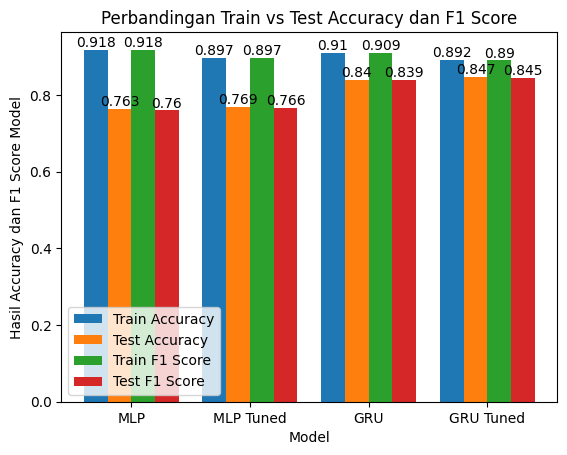

In [ ]:
# Grafik Perbandingan Train vs Test Accuracy dan F1-Score
models = [
    'MLP',
    'MLP Tuned',
    'GRU',
    'GRU Tuned'
]

train_acc = [mlp_train_acc, mlp_train_acc_tuned, gru_train_acc, gru_train_acc_tuned]

test_acc = [mlp_acc, mlp_acc_tuned, gru_acc, gru_acc_tuned]

train_f1 = [mlp_train_f1, mlp_train_f1_tuned, gru_train_f1,gru_train_f1_tuned]

test_f1 = [mlp_f1, mlp_f1_tuned, gru_f1, gru_f1_tuned]

x = np.arange(len(models))
width = 0.2

plt.figure()
plt.bar(x - 1.5 * width, train_acc, width, label='Train Accuracy')
plt.bar(x - 0.5 * width, test_acc, width, label='Test Accuracy')
plt.bar(x + 0.5 * width, train_f1, width, label='Train F1 Score')
plt.bar(x + 1.5 * width, test_f1, width, label='Test F1 Score')

plt.xticks(x, models)
plt.xlabel("Model")
plt.ylabel("Hasil Accuracy dan F1 Score Model")
plt.title("Perbandingan Train vs Test Accuracy dan F1 Score")
plt.legend()

# Tambahkan angka di atas bar
for i in range(len(models)):
    plt.text(x[i] - 1.5 * width, train_acc[i], str(train_acc[i]), ha='center', va='bottom')
    plt.text(x[i] - 0.5 * width, test_acc[i], str(test_acc[i]), ha='center', va='bottom')
    plt.text(x[i] + 0.5 * width, train_f1[i], str(train_f1[i]), ha='center', va='bottom')
    plt.text(x[i] + 1.5 * width, test_f1[i], str(test_f1[i]), ha='center', va='bottom')

plt.show()

In [ ]:
# Evaluasi Per Kelas

# Ambil metrik per kelas (array)
mlp_prec_class = np.round(precision_score(Y_test, Y_test_pred_mlp, average=None), 3)
mlp_rec_class  = np.round(recall_score(Y_test, Y_test_pred_mlp, average=None), 3)
mlp_f1_class   = np.round(f1_score(Y_test, Y_test_pred_mlp, average=None), 3)

gru_prec_class = np.round(precision_score(Y_test, Y_test_pred_gru, average=None),3)
gru_rec_class  = np.round(recall_score(Y_test, Y_test_pred_gru, average=None), 3)
gru_f1_class   = np.round(f1_score(Y_test, Y_test_pred_gru, average=None), 3)

mlp_prec_tuned_class = np.round(precision_score(Y_test, Y_test_pred_mlp_tuned, average=None),3)
mlp_rec_tuned_class  = np.round(recall_score(Y_test, Y_test_pred_mlp_tuned, average=None),3)
mlp_f1_tuned_class   = np.round(f1_score(Y_test, Y_test_pred_mlp_tuned, average=None),3)

gru_prec_tuned_class = np.round(precision_score(Y_test, Y_test_pred_gru_tuned, average=None),3)
gru_rec_tuned_class  = np.round(recall_score(Y_test, Y_test_pred_gru_tuned, average=None),3)
gru_f1_tuned_class   = np.round(f1_score(Y_test, Y_test_pred_gru_tuned, average=None),3)

# Loop supaya bisa dapat hasil evaluasi metrik per kelas
for i, class_name in enumerate(le.classes_):

    df_class = pd.DataFrame({
        'Model': [
            'TF-IDF Features + MLP',
            'TF-IDF Features + MLP (Tuned)',
            'Word2Vec Embeddings + GRU',
            'Word2Vec Embeddings + GRU (Tuned)'
        ],
        'Precision': [
            mlp_prec_class[i],
            mlp_prec_tuned_class[i],
            gru_prec_class[i],
            gru_prec_tuned_class[i]
        ],
        'Recall': [
            mlp_rec_class[i],
            mlp_rec_tuned_class[i],
            gru_rec_class[i],
            gru_rec_tuned_class[i]
        ],
        'F1 Score': [
            mlp_f1_class[i],
            mlp_f1_tuned_class[i],
            gru_f1_class[i],
            gru_f1_tuned_class[i]
        ]
    })

    print(f"\n=== Kelas: {class_name} ===")
    print(df_class.to_string(index=False))


=== Kelas: age ===
                            Model  Precision  Recall  F1 Score
            TF-IDF Features + MLP      0.866   0.926     0.895
    TF-IDF Features + MLP (Tuned)      0.902   0.897     0.899
        Word2Vec Embeddings + GRU      0.987   0.972     0.979
Word2Vec Embeddings + GRU (Tuned)      0.992   0.969     0.981

=== Kelas: ethnicity ===
                            Model  Precision  Recall  F1 Score
            TF-IDF Features + MLP      0.890   0.913     0.901
    TF-IDF Features + MLP (Tuned)      0.890   0.948     0.918
        Word2Vec Embeddings + GRU      0.990   0.976     0.983
Word2Vec Embeddings + GRU (Tuned)      0.985   0.978     0.981

=== Kelas: gender ===
                            Model  Precision  Recall  F1 Score
            TF-IDF Features + MLP      0.841   0.768     0.802
    TF-IDF Features + MLP (Tuned)      0.835   0.808     0.822
        Word2Vec Embeddings + GRU      0.883   0.838     0.860
Word2Vec Embeddings + GRU (Tuned)      0.877   0.

In [ ]:
def get_confusion_matrix_table(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    df_cm = pd.DataFrame(
        cm,
        index=le.classes_,    # label asli (baris)
        columns=le.classes_   # prediksi (kolom)
    )

    return df_cm

In [ ]:
# CONFUSION MATRIX PER KELAS - MLP BASELINE
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

cm_mlp = get_confusion_matrix_table(Y_test, Y_test_pred_mlp)
cm_mlp.index.name = "Actual"
cm_mlp.columns.name = "Predicted"
print("\n=== Confusion Matrix: TF-IDF + MLP ===")
print(cm_mlp.to_string())

# CONFUSION MATRIX PER KELAS - MLP TUNED
cm_mlp_tuned = get_confusion_matrix_table(Y_test, Y_test_pred_mlp_tuned)
cm_mlp_tuned.index.name = "Actual"
cm_mlp_tuned.columns.name = "Predicted"
print("\n=== Confusion Matrix: TF-IDF + MLP (Tuned) ===")
print(cm_mlp_tuned.to_string())

# CONFUSION MATRIX PER KELAS - GRU BASELINE
cm_gru = get_confusion_matrix_table(Y_test, Y_test_pred_gru)
cm_gru.index.name = "Actual"
cm_gru.columns.name = "Predicted"
print("\n=== Confusion Matrix: Word2Vec + GRU ===")
print(cm_gru.to_string())

# CONFUSION MATRIX PER KELAS - GRU TUNED
cm_gru_tuned = get_confusion_matrix_table(Y_test, Y_test_pred_gru_tuned)
cm_gru_tuned.index.name = "Actual"
cm_gru_tuned.columns.name = "Predicted"
print("\n=== Confusion Matrix: Word2Vec + GRU (Tuned) ===")
print(cm_gru_tuned.to_string())


=== Confusion Matrix: TF-IDF + MLP ===
Predicted            age  ethnicity  gender  not_cyberbullying  other_cyberbullying  religion
Actual                                                                                       
age                  725         10       7                 17                   15         9
ethnicity              8        713       5                 17                   18        20
gender                17          9     601                 71                   68        17
not_cyberbullying     45         33      46                369                  251        39
other_cyberbullying   39         31      50                186                  439        25
religion               3          5       6                 26                   16       733

=== Confusion Matrix: TF-IDF + MLP (Tuned) ===
Predicted            age  ethnicity  gender  not_cyberbullying  other_cyberbullying  religion
Actual                                                            